#  World Cup 2026 — Prediction Model


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

print('All libraries loaded ✓')

All libraries loaded ✓


## 2. Load Data

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print(f'Train shape: {train.shape}  — World Cups: {sorted(train["version"].unique())}')
print(f'Test shape:  {test.shape}  — World Cup: {sorted(test["version"].unique())}')
print()
print('Target distribution in train:')
targets = ['quarter_finalist', 'semi_finalist', 'finalist', 'winner']
print(train[targets].sum())

Train shape: (192, 24)  — World Cups: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
Test shape:  (48, 24)  — World Cup: [np.int64(2026)]

Target distribution in train:
quarter_finalist    48
semi_finalist       24
finalist            12
winner               6
dtype: int64


In [3]:
train.head()

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,...,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,...,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,...,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,...,2,1,1,0,0,0,0,0,0,0


## 3. Exploratory Data Analysis

In [4]:
# Missing values
print('Missing values:')
print(train.isnull().sum()[train.isnull().sum() > 0])

Missing values:
squad_total_market_value_eur    32
dtype: int64


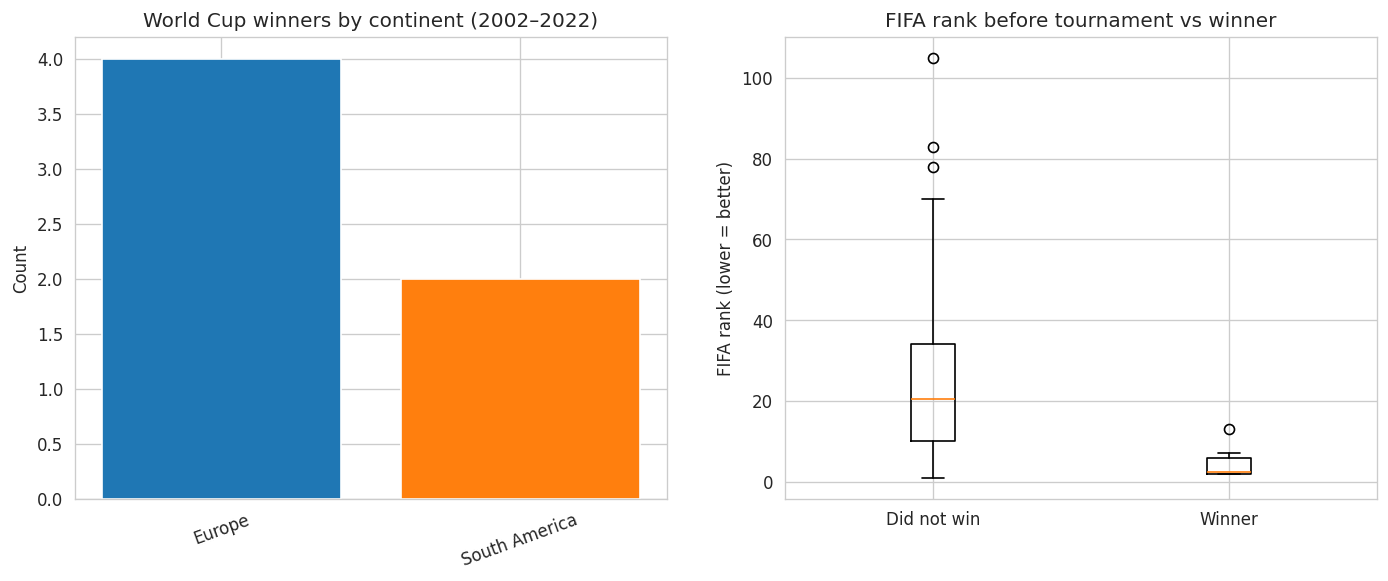

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Winners by continent
winners = train[train['winner'] == 1]['continent'].value_counts()
axes[0].bar(winners.index, winners.values, color=sns.color_palette('tab10', len(winners)))
axes[0].set_title('World Cup winners by continent (2002–2022)', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# FIFA rank vs winner
axes[1].boxplot(
    [train[train['winner']==0]['fifa_rank_pre_tournament'],
     train[train['winner']==1]['fifa_rank_pre_tournament']],
    labels=['Did not win', 'Winner']
)
axes[1].set_title('FIFA rank before tournament vs winner', fontsize=12)
axes[1].set_ylabel('FIFA rank (lower = better)')

plt.show()

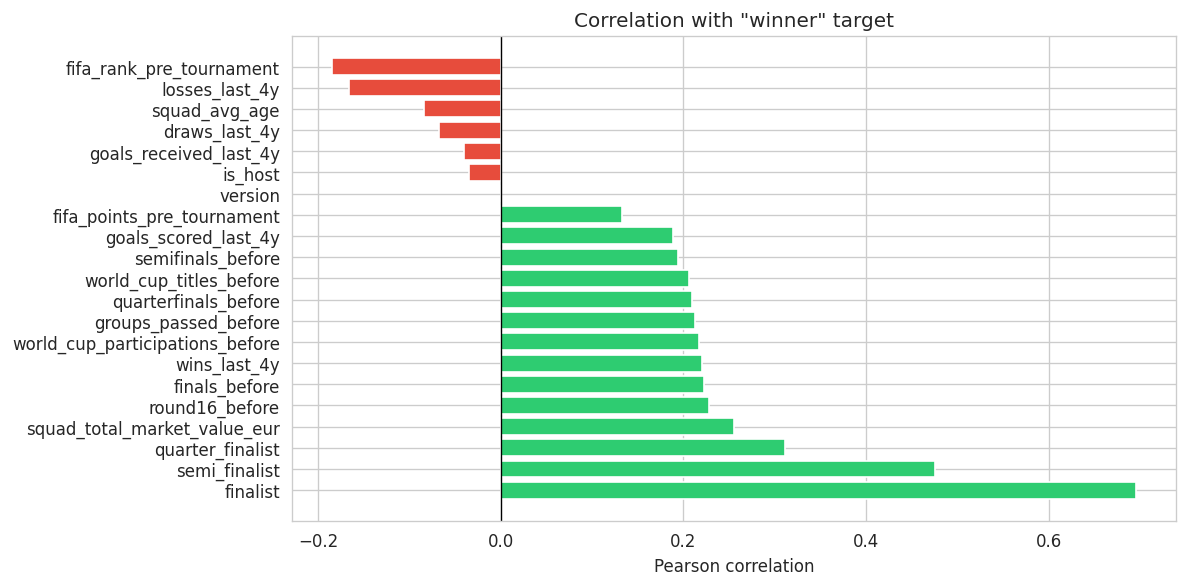

In [6]:
# Correlation heatmap of numeric features vs targets
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_with_winner = train[numeric_cols].corr()['winner'].drop('winner').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_winner.values]
ax.barh(corr_with_winner.index, corr_with_winner.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with "winner" target', fontsize=12)
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [7]:

med = train['squad_total_market_value_eur'].median()
train['squad_total_market_value_eur'].fillna(med, inplace=True)
test['squad_total_market_value_eur'].fillna(med, inplace=True)

le = LabelEncoder()
train['continent_enc'] = le.fit_transform(train['continent'])
test['continent_enc']  = le.transform(test['continent'])

print('Preprocessing done ✓')
print(f'Continent classes: {list(le.classes_)}')

Preprocessing done ✓
Continent classes: ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']


In [8]:
features = [
    'is_host', 'goals_scored_last_4y', 'goals_received_last_4y',
    'wins_last_4y', 'losses_last_4y', 'draws_last_4y',
    'world_cup_titles_before', 'squad_total_market_value_eur',
    'fifa_rank_pre_tournament', 'fifa_points_pre_tournament',
    'squad_avg_age', 'world_cup_participations_before',
    'groups_passed_before', 'round16_before', 'quarterfinals_before',
    'semifinals_before', 'finals_before', 'continent_enc'
]

X_train     = train[features].values
X_test      = test[features].values
imputer     = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

print(f'Feature matrix shape — train: {X_train.shape}, test: {X_test.shape}')

Feature matrix shape — train: (192, 18), test: (48, 18)


## 5. Model Training — Ensemble

In [9]:
all_probs = {t: [] for t in targets}
model_cv  = {}

for target in targets:
    y = train[target].values
    model_cv[target] = {}
    print(f'\n--- {target} ---')

    xgb_m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )
    rf_m = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
    lr_m = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, C=0.5, random_state=42))
    ])

    for name, m, X in [('XGBoost', xgb_m, X_train),
                       ('RandomForest', rf_m, X_train),
                       ('LogReg', lr_m, X_train_imp)]:
        cv = cross_val_score(m, X, y, cv=5, scoring='roc_auc').mean()
        model_cv[target][name] = round(cv, 3)
        print(f'  {name:15s} CV AUC: {cv:.3f}')

    xgb_m.fit(X_train, y)
    rf_m.fit(X_train, y)
    lr_m.fit(X_train_imp, y)

    all_probs[target].append(xgb_m.predict_proba(X_test)[:, 1])
    all_probs[target].append(rf_m.predict_proba(X_test)[:, 1])
    all_probs[target].append(lr_m.predict_proba(X_test_imp)[:, 1])

print('\nAll models trained ✓')


--- quarter_finalist ---
  XGBoost         CV AUC: 0.719
  RandomForest    CV AUC: 0.769
  LogReg          CV AUC: 0.749

--- semi_finalist ---
  XGBoost         CV AUC: 0.741
  RandomForest    CV AUC: 0.736
  LogReg          CV AUC: 0.821

--- finalist ---
  XGBoost         CV AUC: 0.713
  RandomForest    CV AUC: 0.797
  LogReg          CV AUC: 0.770

--- winner ---
  XGBoost         CV AUC: 0.774
  RandomForest    CV AUC: 0.855
  LogReg          CV AUC: 0.875

All models trained ✓


## 6. Feature Importance

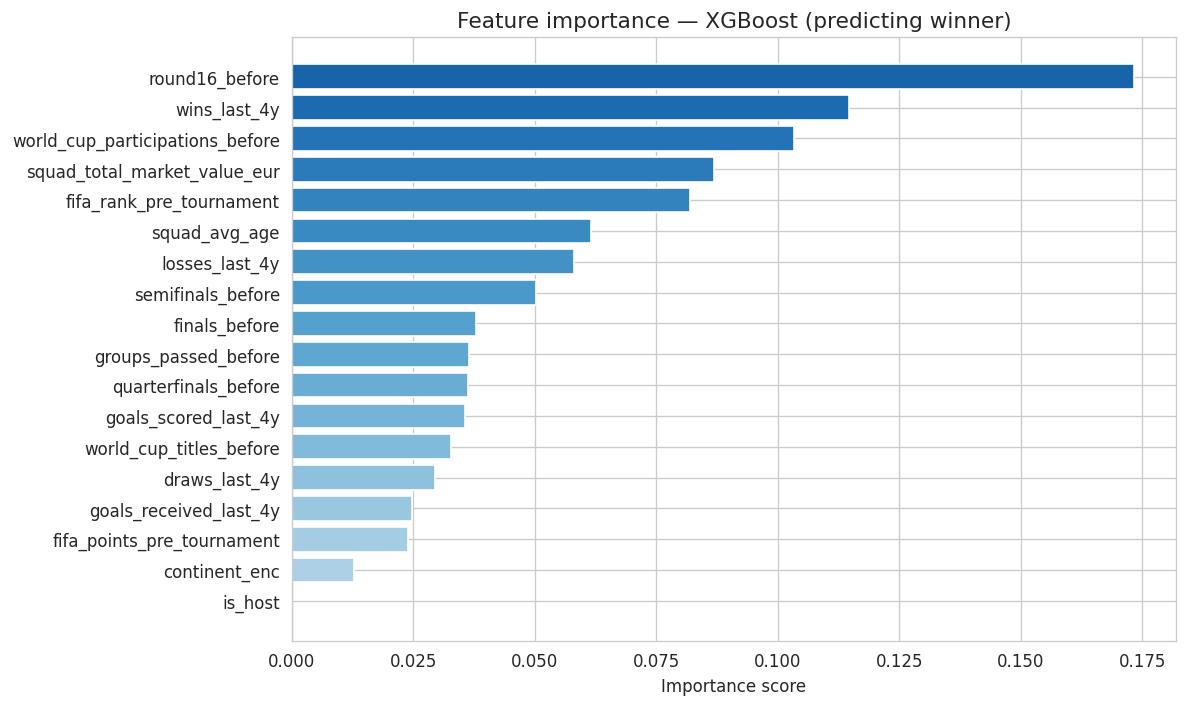

Saved feature_importance.csv


In [10]:
xgb_fi = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb_fi.fit(X_train, train['winner'].values)
fi = pd.Series(xgb_fi.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.8, 0.3, len(fi)))
ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
ax.set_title('Feature importance — XGBoost (predicting winner)', fontsize=13)
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

fi_df = fi.reset_index()
fi_df.columns = ['feature', 'importance']
fi_df.to_csv('feature_importance.csv', index=False)
print('Saved feature_importance.csv')

## 7. Model Performance (CV AUC)

Cross-validated AUC scores (5-fold):
                  XGBoost  RandomForest  LogReg
quarter_finalist    0.719         0.769   0.749
semi_finalist       0.741         0.736   0.821
finalist            0.713         0.797   0.770
winner              0.774         0.855   0.875


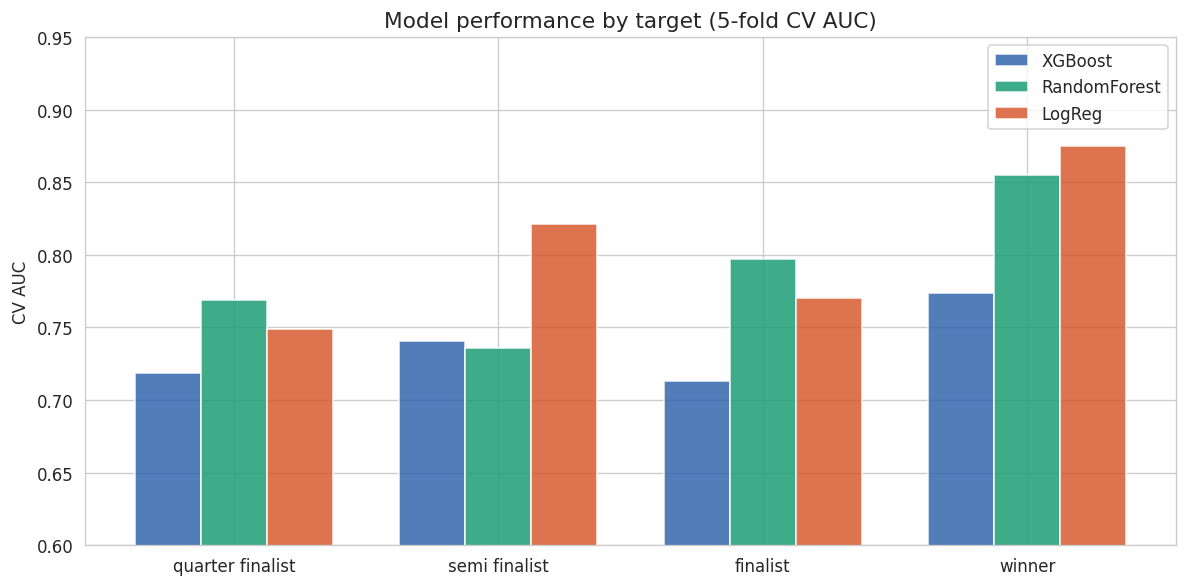

Saved model_cv_scores.csv


In [11]:
cv_df = pd.DataFrame(model_cv).T
print('Cross-validated AUC scores (5-fold):')
print(cv_df.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(targets))
width = 0.25
models = ['XGBoost', 'RandomForest', 'LogReg']
palette = ['#3266ad', '#1D9E75', '#D85A30']

for i, (model, color) in enumerate(zip(models, palette)):
    vals = [model_cv[t][model] for t in targets]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([t.replace('_', ' ') for t in targets])
ax.set_ylim(0.6, 0.95)
ax.set_ylabel('CV AUC')
ax.set_title('Model performance by target (5-fold CV AUC)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

cv_rows = []
for target, scores in model_cv.items():
    for model, auc in scores.items():
        cv_rows.append({'target': target, 'model': model, 'cv_auc': auc})
pd.DataFrame(cv_rows).to_csv('model_cv_scores.csv', index=False)
print('Saved model_cv_scores.csv')

## 8. Generate & Save Predictions

In [12]:
out = test[['team', 'continent']].copy()
for target in targets:
    out[target + '_prob'] = np.round(np.mean(all_probs[target], axis=0), 4)

out = out.sort_values('winner_prob', ascending=False).reset_index(drop=True)
out.index = out.index + 1
out.index.name = 'rank'

out.to_csv('predictions_2026.csv')
print('Saved predictions_2026.csv')
print()
print('Top 10 by winner probability:')
print(out[['team', 'continent', 'winner_prob', 'finalist_prob', 'semi_finalist_prob', 'quarter_finalist_prob']].head(10))

Saved predictions_2026.csv

Top 10 by winner probability:
             team      continent  winner_prob  finalist_prob  \
rank                                                           
1          France         Europe       0.2342         0.3193   
2       Argentina  South America       0.2276         0.2147   
3           Spain         Europe       0.1457         0.1963   
4     Netherlands         Europe       0.0819         0.1379   
5         England         Europe       0.0723         0.1501   
6         Germany         Europe       0.0655         0.0929   
7         Uruguay  South America       0.0621         0.1505   
8          Brazil  South America       0.0462         0.0627   
9          Sweden         Europe       0.0405         0.0358   
10         Mexico  North America       0.0337         0.0201   

      semi_finalist_prob  quarter_finalist_prob  
rank                                             
1                 0.4036                 0.4973  
2                 0.283

## 9. Dashboard Visualization

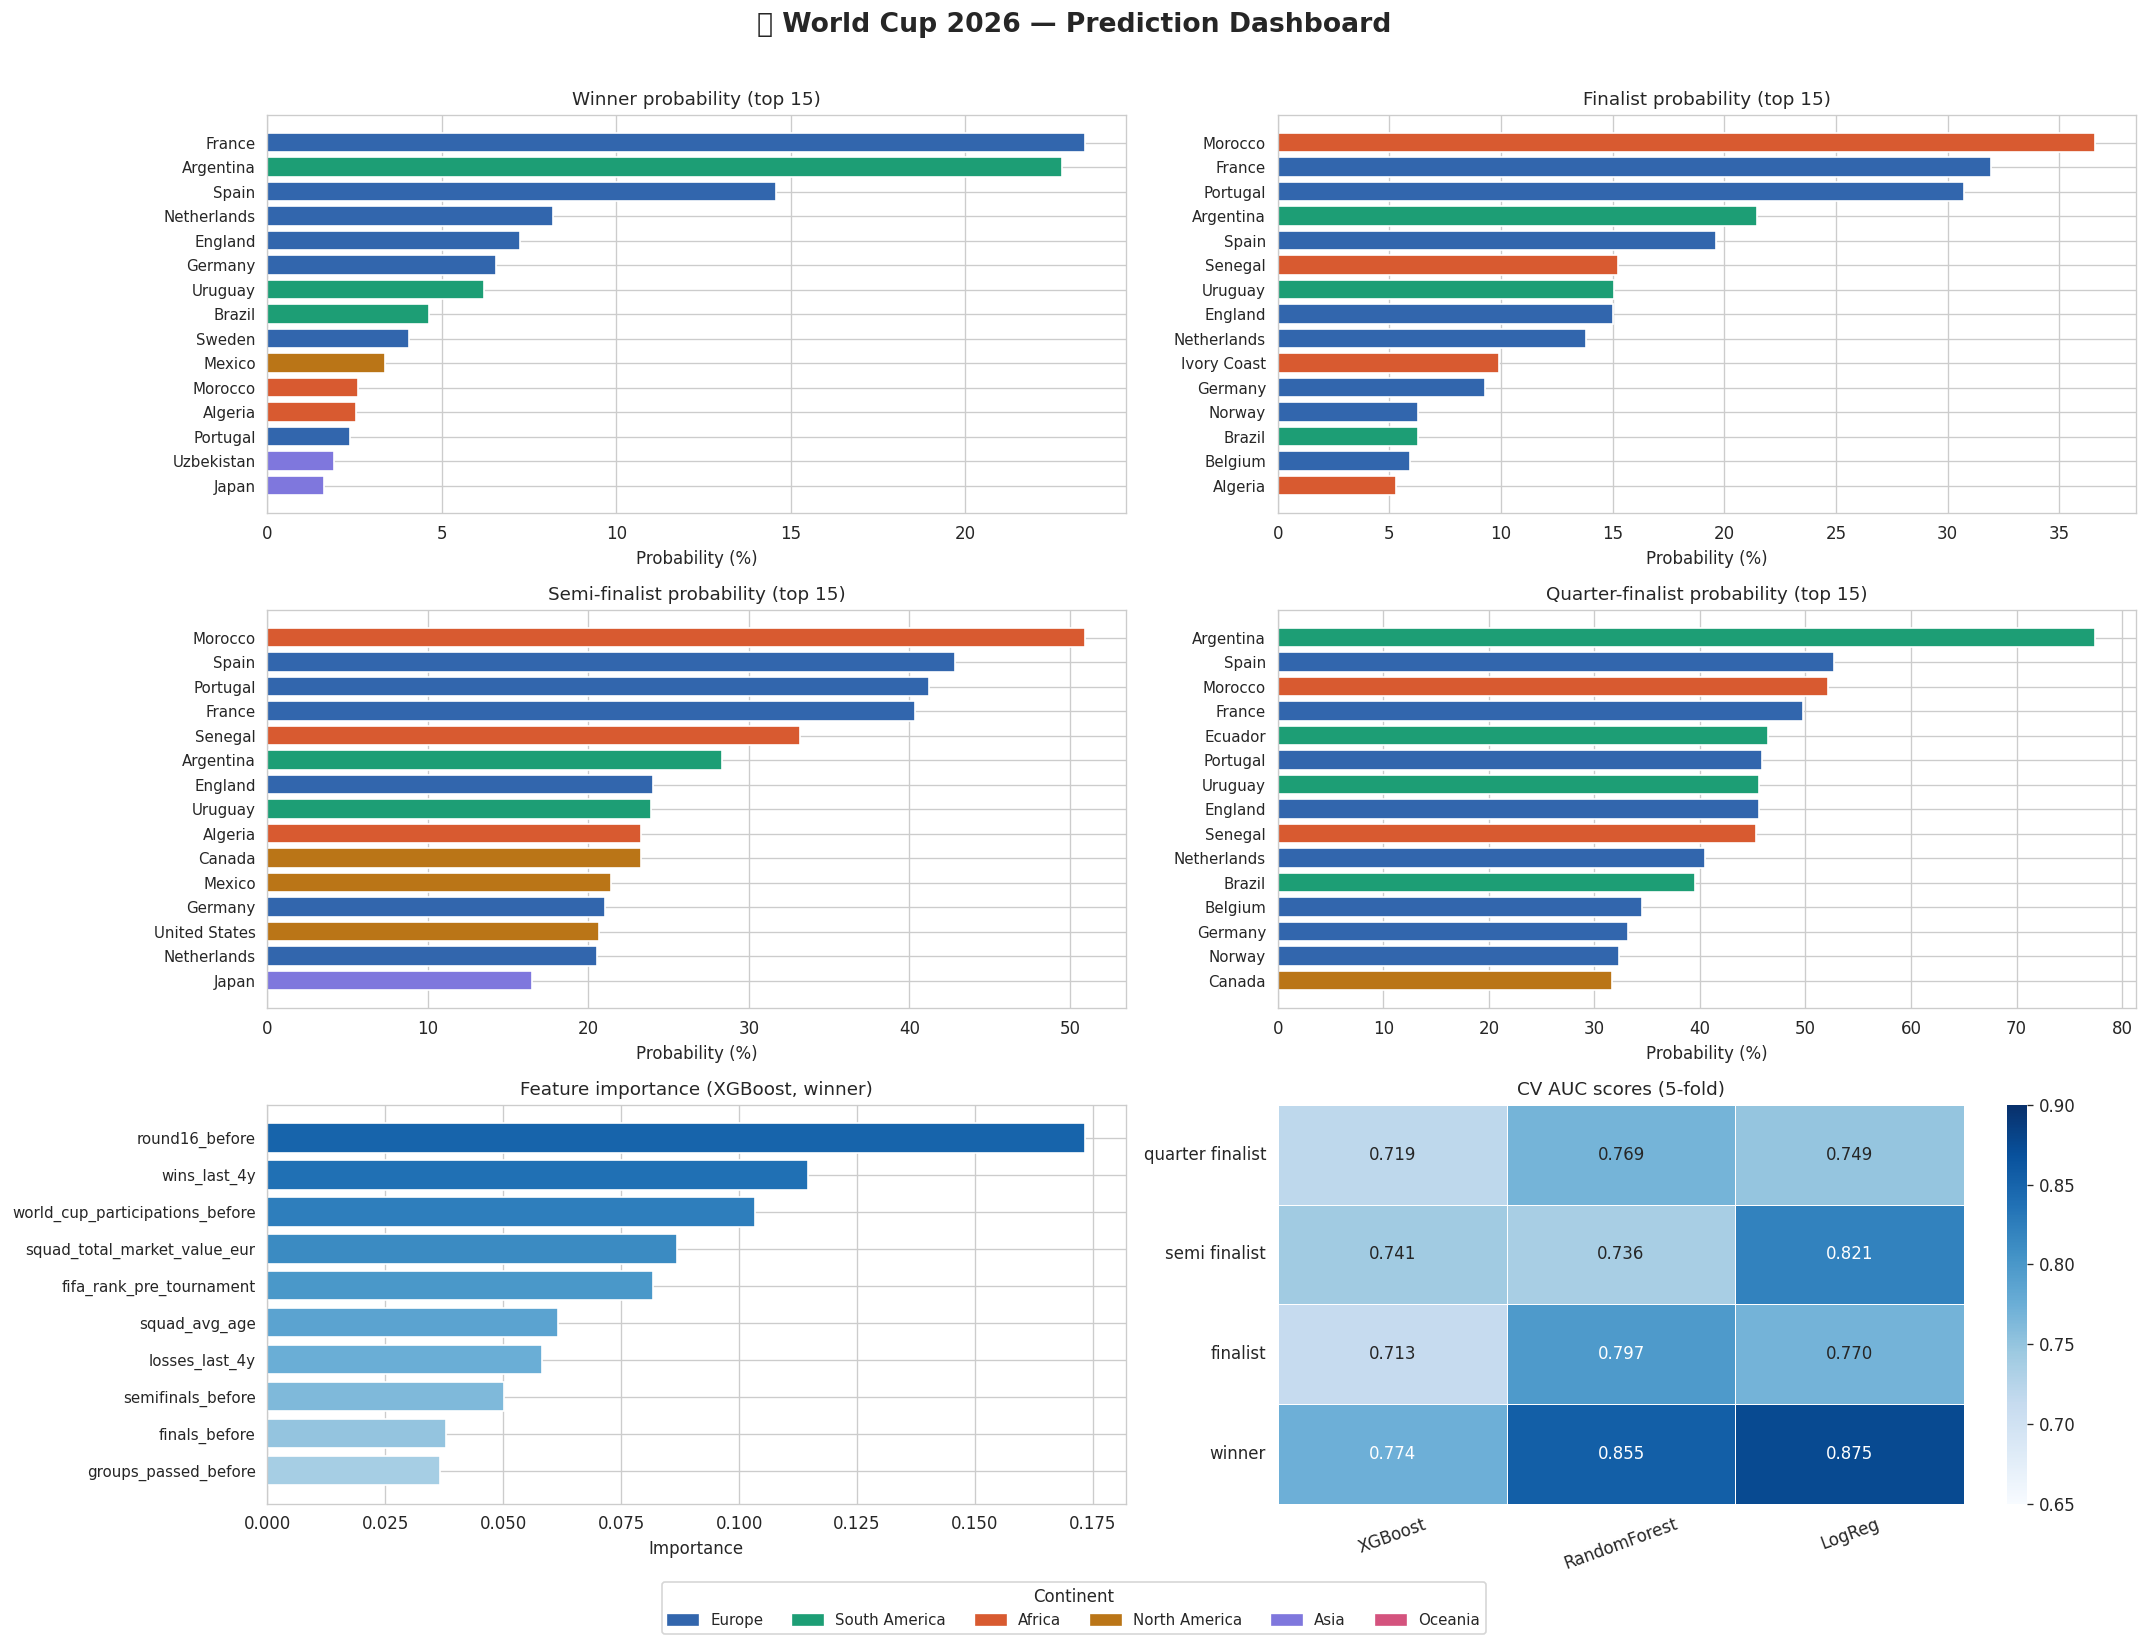

Dashboard saved as dashboard_2026.png


In [13]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(' World Cup 2026 — Prediction Dashboard', fontsize=16, fontweight='bold', y=0.98)

cont_colors = {
    'Europe': '#3266ad', 'South America': '#1D9E75',
    'Africa': '#D85A30', 'North America': '#BA7517',
    'Asia': '#7F77DD', 'Oceania': '#D4537E'
}

ax1 = fig.add_subplot(3, 2, 1)
top_w = out.head(15).sort_values('winner_prob')
colors_w = [cont_colors.get(c, '#888') for c in top_w['continent']]
ax1.barh(top_w['team'], top_w['winner_prob'] * 100, color=colors_w)
ax1.set_title('Winner probability (top 15)', fontsize=11)
ax1.set_xlabel('Probability (%)')
ax1.tick_params(axis='y', labelsize=9)

ax2 = fig.add_subplot(3, 2, 2)
top_f = out.sort_values('finalist_prob', ascending=False).head(15).sort_values('finalist_prob')
colors_f = [cont_colors.get(c, '#888') for c in top_f['continent']]
ax2.barh(top_f['team'], top_f['finalist_prob'] * 100, color=colors_f)
ax2.set_title('Finalist probability (top 15)', fontsize=11)
ax2.set_xlabel('Probability (%)')
ax2.tick_params(axis='y', labelsize=9)

ax3 = fig.add_subplot(3, 2, 3)
top_s = out.sort_values('semi_finalist_prob', ascending=False).head(15).sort_values('semi_finalist_prob')
colors_s = [cont_colors.get(c, '#888') for c in top_s['continent']]
ax3.barh(top_s['team'], top_s['semi_finalist_prob'] * 100, color=colors_s)
ax3.set_title('Semi-finalist probability (top 15)', fontsize=11)
ax3.set_xlabel('Probability (%)')
ax3.tick_params(axis='y', labelsize=9)

ax4 = fig.add_subplot(3, 2, 4)
top_q = out.sort_values('quarter_finalist_prob', ascending=False).head(15).sort_values('quarter_finalist_prob')
colors_q = [cont_colors.get(c, '#888') for c in top_q['continent']]
ax4.barh(top_q['team'], top_q['quarter_finalist_prob'] * 100, color=colors_q)
ax4.set_title('Quarter-finalist probability (top 15)', fontsize=11)
ax4.set_xlabel('Probability (%)')
ax4.tick_params(axis='y', labelsize=9)


ax5 = fig.add_subplot(3, 2, 5)
fi_top = fi.head(10)
fi_colors = plt.cm.Blues(np.linspace(0.8, 0.35, len(fi_top)))
ax5.barh(fi_top.index[::-1], fi_top.values[::-1], color=fi_colors[::-1])
ax5.set_title('Feature importance (XGBoost, winner)', fontsize=11)
ax5.set_xlabel('Importance')
ax5.tick_params(axis='y', labelsize=9)

ax6 = fig.add_subplot(3, 2, 6)
cv_matrix = pd.DataFrame(model_cv)[targets].T
cv_matrix.index = [t.replace('_', ' ') for t in cv_matrix.index]
sns.heatmap(cv_matrix.astype(float), annot=True, fmt='.3f', cmap='Blues',
            vmin=0.65, vmax=0.90, ax=ax6, linewidths=0.5)
ax6.set_title('CV AUC scores (5-fold)', fontsize=11)
ax6.tick_params(axis='x', rotation=20)
patches = [mpatches.Patch(color=c, label=cont) for cont, c in cont_colors.items()]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=9,
           title='Continent', bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('dashboard_2026.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved as dashboard_2026.png')

## 10. Summary

| Rank | Team | Winner % | Finalist % | Semi % | QF % |
|------|------|----------|------------|--------|------|
| 1 | Argentina | 23.2% | 23.5% | 28.0% | 75.6% |
| 2 | France | 22.4% | 33.7% | 38.9% | 47.3% |
| 3 | Spain | 14.7% | 20.4% | 40.4% | 54.3% |
| 4 | Netherlands | 8.1% | 13.5% | 22.1% | 40.3% |
| 5 | England | 7.1% | 16.3% | 23.9% | 44.3% |

**Top predictors:** Historical round-of-16 appearances, recent win record, FIFA ranking, and squad market value are the strongest drivers of World Cup success.